In [1]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
img = cv2.imread('./test_images/saina_nehwal_1.jpg')
img.shape

(270, 480, 3)

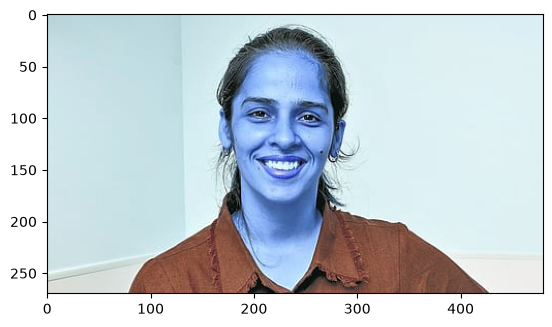

In [3]:
plt.imshow(img)

In [4]:
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(270, 480)

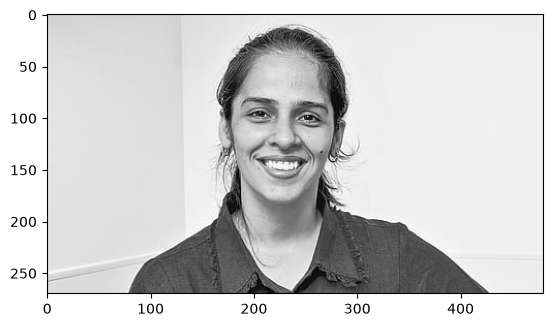

In [5]:
plt.imshow(gray, cmap='gray')

In [6]:
face_cascade=cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade=cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')

faces=face_cascade.detectMultiScale(gray,1.3,5)
faces

array([[165,  46, 128, 128]], dtype=int32)

In [7]:
(x,y,w,h)=faces[0]
x,y,w,h

(np.int32(165), np.int32(46), np.int32(128), np.int32(128))

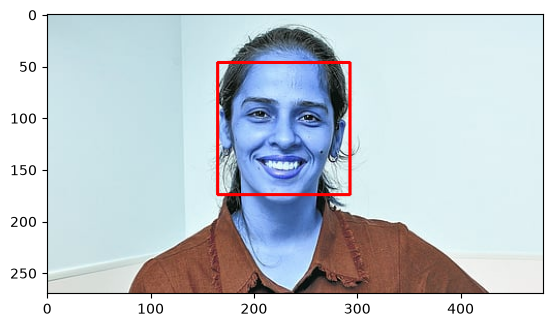

In [8]:
face_img = cv2.rectangle(img,(x,y),(x+w, y+h),(255,0,0),2)
plt.imshow(face_img)

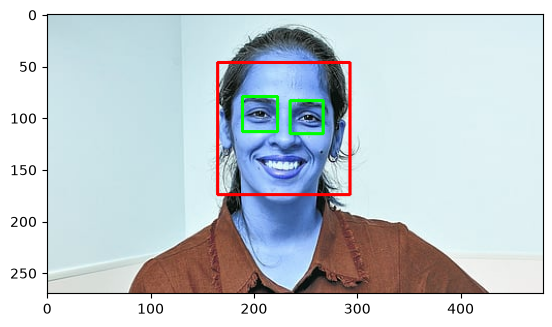

In [9]:
cv2.destroyAllWindows()

for(x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w, y+h),(255,0,0,2))
    roi_gray=gray[y:y+h , x:x+w]
    roi_color=face_img[y:y+h,x:x+w]
    eyes = eye_cascade. detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

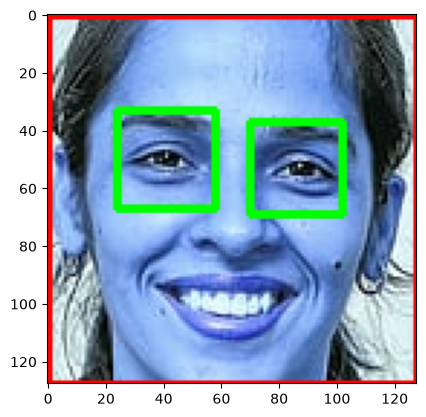

In [10]:
plt.imshow(roi_color,cmap='gray')

In [11]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Could not read:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) >= 2:
            return roi_color

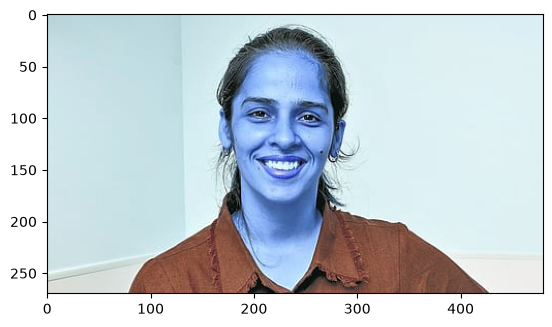

In [12]:
original_image = cv2.imread('./test_images/saina_nehwal_1.jpg')
plt.imshow(original_image)

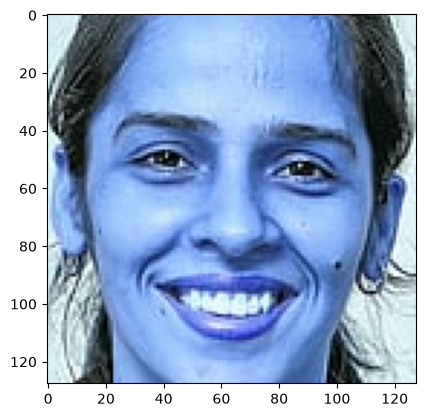

In [13]:
cropped_image = get_cropped_image_if_2_eyes('./test_images/saina_nehwal_1.jpg')
plt.imshow(cropped_image)

In [14]:
path_to_data = './dataset'
path_to_cr_data = "dataset/cropped"

In [15]:
import os 
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir() and entry.name != "cropped":
        img_dirs.append(entry.path) 

In [16]:
img_dirs

['./dataset\\cristiano_ronaldo',
 './dataset\\gukesh_dommaraju',
 './dataset\\lionel_messi',
 './dataset\\saina_nehwal',
 './dataset\\virat_kohli']

In [17]:
import shutil 
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [18]:
cropped_image_dirs =[]
sports_person_file_names_dict ={}

for img_dir in img_dirs :
    count=1
    sports_person_name = img_dir.split('\\')[-1]
    sports_person_file_names_dict[sports_person_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = os.path.join(path_to_cr_data, sports_person_name)
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Geneating cropped images in folder:",cropped_folder)

            cropped_file_name = sports_person_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name

            cv2.imwrite(cropped_file_path, roi_color)
            sports_person_file_names_dict[sports_person_name].append(cropped_file_path)
            count+=1

Geneating cropped images in folder: dataset/cropped\cristiano_ronaldo
Geneating cropped images in folder: dataset/cropped\gukesh_dommaraju
Geneating cropped images in folder: dataset/cropped\lionel_messi
Geneating cropped images in folder: dataset/cropped\saina_nehwal
Geneating cropped images in folder: dataset/cropped\virat_kohli


In [19]:
import numpy as np
import pywt
import cv2
def w2d (img, mode='haar', level=1):
    imArray = img
    imArray = cv2.cvtColor(imArray,cv2.COLOR_RGB2GRAY)
    imArray = np.float32(imArray)
    imArray /=255
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *=255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

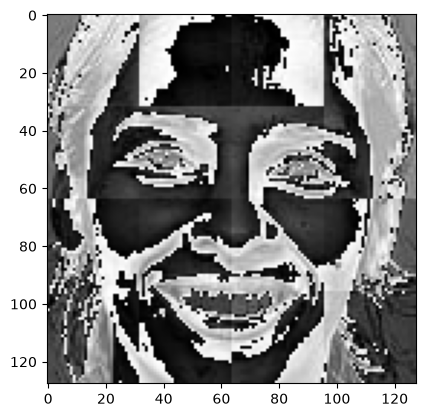

In [20]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har,cmap='gray')

In [21]:
sports_person_file_names_dict

{'cristiano_ronaldo': ['dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo1.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo2.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo3.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo4.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo5.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo6.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo7.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo8.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo9.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo10.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo11.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo12.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo13.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo14.png',
  'dataset/cropped\\cristiano_ronaldo/cristiano_ronaldo15.png',
  'dataset/cropped\\cristian

In [22]:
#Assigning numbers to each sports person

class_dict={}
count=0
for sports_person_name in sports_person_file_names_dict.keys():
    class_dict[sports_person_name]=count
    count=count+1
class_dict

{'cristiano_ronaldo': 0,
 'gukesh_dommaraju': 1,
 'lionel_messi': 2,
 'saina_nehwal': 3,
 'virat_kohli': 4}

In [23]:
X=[]
y=[]

for sports_person_name, training_files in sports_person_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scaled_raw_img=cv2.resize(img,(32,32))
        img_har = w2d(img,'db1',5)
        scaled_img_har = cv2.resize(img_har,(32,32))
        combined_img = np.vstack((scaled_raw_img.reshape(32*32*3,1),scaled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[sports_person_name])

In [24]:
len(X)

188

In [25]:
X=np.array(X).reshape(len(X),4096).astype(float)
X.shape

(188, 4096)

In [26]:
X[0]

array([126.,  88., 117., ...,   0.,  26.,  40.], shape=(4096,))

In [27]:
from sklearn.svm import SVC 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn. metrics import classification_report

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('svc',SVC(kernel='rbf',C=10))
])

pipe.fit(X_train, y_train)

pipe.score(X_test, y_test)

0.8723404255319149

In [29]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       0.90      1.00      0.95         9
           2       1.00      0.60      0.75        10
           3       1.00      1.00      1.00         7
           4       0.90      0.82      0.86        11

    accuracy                           0.87        47
   macro avg       0.90      0.88      0.88        47
weighted avg       0.90      0.87      0.87        47



In [30]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [31]:
model_params = {
    'svm' : {
        'model':svm.SVC(gamma = 'auto',probability=True),
        'params' : {
            'svc__C' : [1,10,100,1000],
            'svc__kernel' : ['rbf', 'linear']
        }
    },
    'random_forest' : {
        'model':RandomForestClassifier(),
        'params': {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(),
        'params' : {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [32]:
scores=[]
best_estimators={}
import pandas as pd

for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(),mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo, 
        'best_score':clf.best_score_,
        'best_params':clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df= pd.DataFrame(scores, columns=['model','best_score','best_params'])
df

d:\Miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

,model,best_score,best_params
0,svm,0.894089,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.724138,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.894089,{'logisticregression__C': 1}


In [33]:
best_estimators['svm'].score(X_test, y_test)

0.9148936170212766

In [34]:
best_estimators['random_forest'].score(X_test, y_test)

0.6808510638297872

In [35]:
best_estimators['logistic_regression'].score(X_test, y_test)

0.9148936170212766

In [36]:
best_clf = best_estimators['svm']

In [37]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[10,  0,  0,  0,  0],
       [ 0,  9,  0,  0,  0],
       [ 2,  0,  8,  0,  0],
       [ 0,  0,  0,  7,  0],
       [ 0,  2,  0,  0,  9]])

Text(95.83333333333333, 0.5, 'Truth')

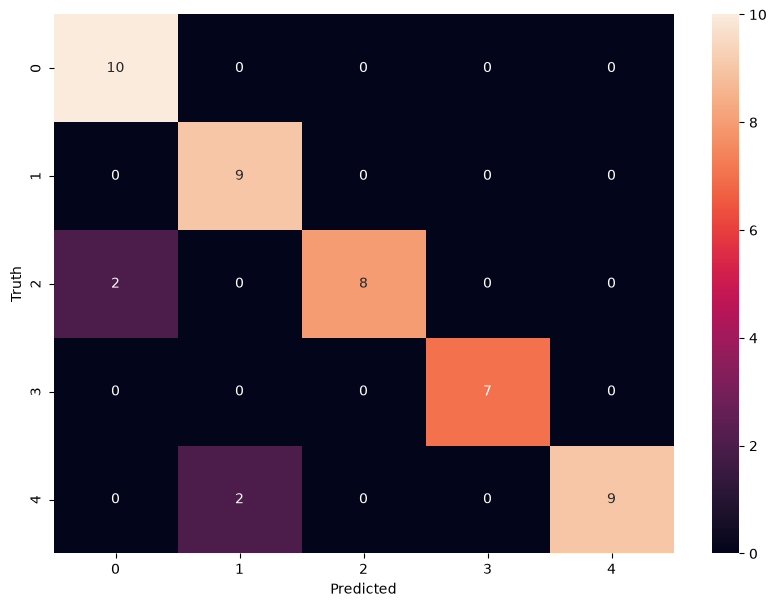

In [38]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [39]:
class_dict

{'cristiano_ronaldo': 0,
 'gukesh_dommaraju': 1,
 'lionel_messi': 2,
 'saina_nehwal': 3,
 'virat_kohli': 4}

In [40]:
import joblib

joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [41]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))